In [ ]:
import pandas as pd
best_backend_df = pd.read_csv("./final_data/best_backend_df.csv")
estimate_runtime_df = pd.read_csv("./final_data/estimate_runtime_df.csv")
print("Loaded CSVs from disk.")

from sklearn.preprocessing import OneHotEncoder

def preprocess_df(df):
	categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
	numeric_cols = df.select_dtypes(exclude=["object"]).columns.tolist()

	# Version-safe OneHotEncoder
	try:
		ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn >=1.2
	except TypeError:
		ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)        # sklearn <1.2

	if categorical_cols:
		encoded_array = ohe.fit_transform(df[categorical_cols])
		encoded_cols = ohe.get_feature_names_out(categorical_cols)
		encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)
		processed_df = pd.concat([df[numeric_cols], encoded_df], axis=1)
	else:
		processed_df = df[numeric_cols].copy()

	return processed_df

best_backend_df_processed = preprocess_df(best_backend_df)
estimate_runtime_df_processed = preprocess_df(estimate_runtime_df)

print("best_backend_df_processed shape:", best_backend_df_processed.shape)
print("estimate_runtime_df_processed shape:", estimate_runtime_df_processed.shape)

Loaded CSVs from disk.
best_backend_df_processed shape: (79, 72)
estimate_runtime_df_processed shape: (307, 89)


## 2. Colors & Matplotlib styles

Defines a colorblind-friendly palette if `colors` is not already defined. Uses **matplotlib only**.

In [2]:
import matplotlib.pyplot as plt

# Define colors if not already present
if 'colors' not in globals():
	colors = [
		"#4E79A7", "#F28E2B", "#E15759", "#76B7B2",
		"#59A14F", "#EDC948", "#B07AA1", "#FF9DA7",
		"#9C755F", "#BAB0AC"
	]

# Matplotlib font sizes (adjust as needed)
TITLE_FONTSIZE = 16
LABEL_FONTSIZE = 14
TICK_FONTSIZE = 12
GRID_ALPHA = 0.6

## 3. Circuit features selection

We prefer an explicit feature list; if some are missing, we auto-include numeric columns that look like circuit descriptors (including those with `gate_` prefix).

In [3]:
import numpy as np
import pandas as pd

# Build circuit_features for the processed runtime DF
all_cols = estimate_runtime_df_processed.columns.tolist()

# Start from explicit list but keep only those present
circuit_features = [c for c in ["n_qubits", "depth", "width", "n_clbits", "n_ops", "n_gates", "n_parameters", "n_connected_components", "n_measure_ops", "single_qubit_gates", "two_qubit_gates", "three_qubit_gates", "four_qubit_gates", "num_separable_circuits", "num_tensor_factors", "num_serial_layers", "qc_width_total", "num_registers", "num_cregs", "num_ancillas", "idle_wires", "global_phase", "dag_size_ops", "dag_edge_count", "longest_path_len", "num_control_flow_ops", "num_barriers", "num_distinct_twoq_pairs", "touch_min", "touch_max", "touch_avg", "clifford_count", "nonclifford_count", "measure_fraction", "total_gate_params", "avg_gate_params", "std_gate_params", "min_gate_params", "max_gate_params", "num_controlled_gates", "num_unitary_factors", "dag_duration", "qc_duration", "gate_barrier", "gate_ccx", "gate_cp", "gate_cu", "gate_cx", "gate_cz", "gate_h", "gate_measure", "gate_p", "gate_rx", "gate_ry", "gate_rz", "gate_s", "gate_swap", "gate_u2"] if c in all_cols]

# Auto-include numeric columns that look like circuit descriptors
auto_candidates = [
	c for c in all_cols
	if (c.startswith("gate_") or c in [
		"n_qubits","depth","width","n_ops","n_gates","n_parameters","n_connected_components",
		"n_measure_ops","single_qubit_gates","two_qubit_gates","three_qubit_gates","four_qubit_gates",
		"num_separable_circuits","num_tensor_factors","num_serial_layers","qc_width_total",
		"num_registers","num_cregs","num_ancillas","idle_wires","global_phase","dag_size_ops",
		"dag_edge_count","longest_path_len","num_control_flow_ops","num_barriers",
		"num_distinct_twoq_pairs","touch_min","touch_max","touch_avg","clifford_count",
		"nonclifford_count","measure_fraction","total_gate_params","avg_gate_params","std_gate_params",
		"min_gate_params","max_gate_params","num_controlled_gates","num_unitary_factors",
		"dag_duration","qc_duration"
	])
]

# Merge and deduplicate
circuit_features = sorted(set(circuit_features) | set(auto_candidates))

print("Number of circuit_features selected:", len(circuit_features))
print("First 20 circuit_features:", circuit_features[:20])

Number of circuit_features selected: 58
First 20 circuit_features: ['avg_gate_params', 'clifford_count', 'dag_duration', 'dag_edge_count', 'dag_size_ops', 'depth', 'four_qubit_gates', 'gate_barrier', 'gate_ccx', 'gate_cp', 'gate_cu', 'gate_cx', 'gate_cz', 'gate_h', 'gate_measure', 'gate_p', 'gate_rx', 'gate_ry', 'gate_rz', 'gate_s']


## 4. Correlation among circuit features

We compute an absolute correlation matrix and list all pairs above a chosen threshold.

Highly correlated pairs (>|0.95|): 173 found
dag_size_ops             <-> num_serial_layers        : 1.000
gate_barrier             <-> num_barriers             : 1.000
gate_ccx                 <-> three_qubit_gates        : 1.000
gate_measure             <-> n_clbits                 : 1.000
gate_measure             <-> n_measure_ops            : 1.000
gate_measure             <-> n_qubits                 : 1.000
gate_measure             <-> qc_width_total           : 1.000
gate_measure             <-> width                    : 1.000
n_clbits                 <-> n_measure_ops            : 1.000
n_clbits                 <-> n_qubits                 : 1.000
n_clbits                 <-> qc_width_total           : 1.000
n_clbits                 <-> width                    : 1.000
n_gates                  <-> n_ops                    : 1.000
n_measure_ops            <-> n_qubits                 : 1.000
n_measure_ops            <-> qc_width_total           : 1.000
n_measure_ops            

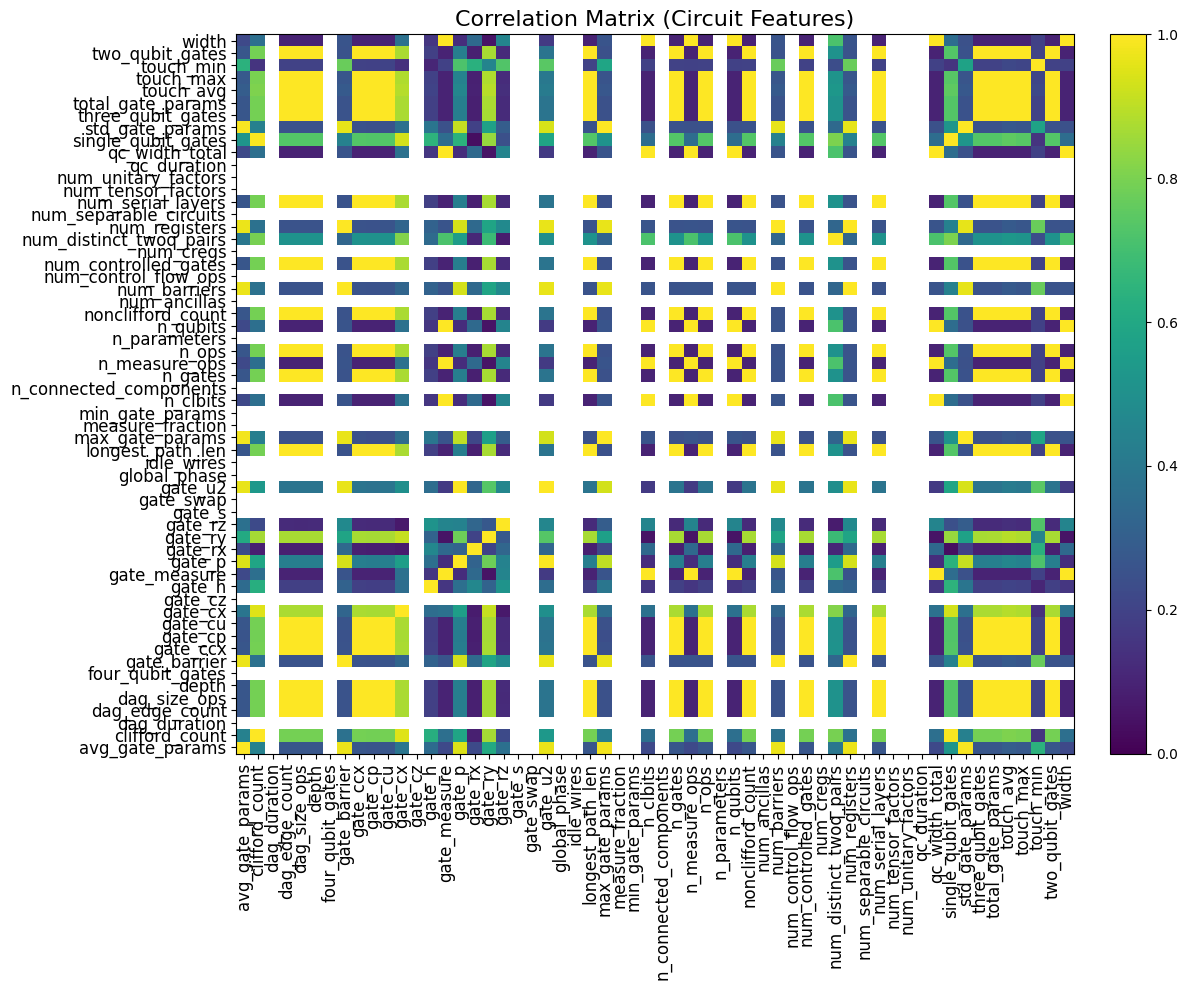

In [4]:
import numpy as np

# X matrix for circuit-only
X_circuit = estimate_runtime_df_processed[circuit_features].copy()

# Correlation matrix (absolute)
corr_matrix = X_circuit.corr().abs()

# List highly correlated pairs
threshold = 0.95  # configurable
pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
	for j in range(i+1, len(cols)):
		c = corr_matrix.iloc[i, j]
		if c > threshold:
			pairs.append((cols[i], cols[j], float(c)))

# Print a sorted list
pairs_sorted = sorted(pairs, key=lambda x: -x[2])
print(f"Highly correlated pairs (>|{threshold:.2f}|): {len(pairs_sorted)} found")
for a,b,c in pairs_sorted[:50]:
	print(f"{a:24s} <-> {b:24s} : {c:.3f}")
if len(pairs_sorted) > 50:
	print(f"... and {len(pairs_sorted)-50} more")

# Plot correlation matrix (matplotlib only)
plt.figure(figsize=(12, 10))
im = plt.imshow(corr_matrix.values, vmin=0, vmax=1, origin='lower', aspect='auto')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(cols)), cols, rotation=90, fontsize=TICK_FONTSIZE)
plt.yticks(range(len(cols)), cols, fontsize=TICK_FONTSIZE)
plt.title("Correlation Matrix (Circuit Features)", fontsize=TITLE_FONTSIZE)
plt.tight_layout()
plt.show()

Highly correlated pairs (>|0.95|): 173 found
dag_size_ops             <-> num_serial_layers        : 1.000
gate_barrier             <-> num_barriers             : 1.000
gate_ccx                 <-> three_qubit_gates        : 1.000
gate_measure             <-> n_clbits                 : 1.000
gate_measure             <-> n_measure_ops            : 1.000
gate_measure             <-> n_qubits                 : 1.000
gate_measure             <-> qc_width_total           : 1.000
gate_measure             <-> width                    : 1.000
n_clbits                 <-> n_measure_ops            : 1.000
n_clbits                 <-> n_qubits                 : 1.000
n_clbits                 <-> qc_width_total           : 1.000
n_clbits                 <-> width                    : 1.000
n_gates                  <-> n_ops                    : 1.000
n_measure_ops            <-> n_qubits                 : 1.000
n_measure_ops            <-> qc_width_total           : 1.000
n_measure_ops            

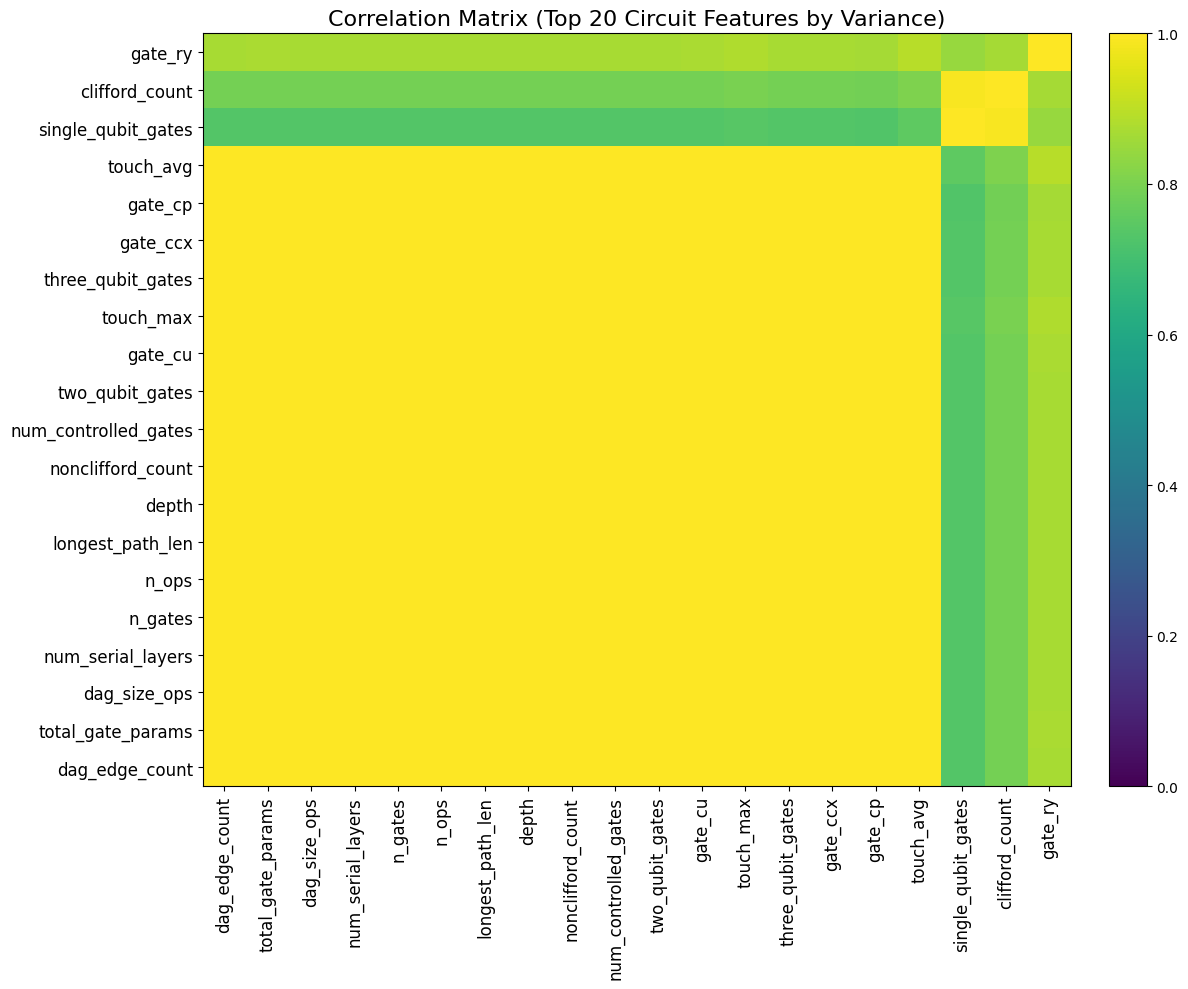

In [6]:
import numpy as np

# X matrix for circuit-only
X_circuit = estimate_runtime_df_processed[circuit_features].copy()

# Correlation matrix (absolute)
corr_matrix = X_circuit.corr().abs()

# List highly correlated pairs (global)
threshold = 0.95  # configurable
pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        c = corr_matrix.iloc[i, j]
        if c > threshold:
            pairs.append((cols[i], cols[j], float(c)))

pairs_sorted = sorted(pairs, key=lambda x: -x[2])
print(f"Highly correlated pairs (>|{threshold:.2f}|): {len(pairs_sorted)} found")
for a, b, c in pairs_sorted[:50]:
    print(f"{a:24s} <-> {b:24s} : {c:.3f}")
if len(pairs_sorted) > 50:
    print(f"... and {len(pairs_sorted)-50} more")

# -----------------------------
# Smaller, more readable heatmap
# -----------------------------
# Choose a manageable subset of columns to plot
TOP_N = 20  # <= adjust this to 20/30/etc. for fewer rows/cols

# Option 1: pick features with highest variance
var_rank = X_circuit.var().sort_values(ascending=False)
chosen = var_rank.index[:min(TOP_N, len(var_rank))].tolist()

# (Optional) Option 2: pick features with highest average absolute correlation
# avg_corr_rank = corr_matrix.replace(1.0, np.nan).mean().sort_values(ascending=False)
# chosen = avg_corr_rank.index[:min(TOP_N, len(avg_corr_rank))].tolist()

sub_corr = corr_matrix.loc[chosen, chosen]

# Fallback sizes if style vars not set
try:
    TITLE_FONTSIZE
except NameError:
    TITLE_FONTSIZE = 16
try:
    TICK_FONTSIZE
except NameError:
    TICK_FONTSIZE = 12

# Plot correlation matrix (subset; matplotlib only)
plt.figure(figsize=(12, 10))
im = plt.imshow(sub_corr.values, vmin=0, vmax=1, origin='lower', aspect='auto')
plt.colorbar(im, fraction=0.046, pad=0.04)

# Optionally thin tick labels for readability (every nth)
step = max(1, len(chosen) // 24)  # show ~≤24 ticks
plt.xticks(range(0, len(chosen), step), [chosen[i] for i in range(0, len(chosen), step)],
           rotation=90, fontsize=TICK_FONTSIZE)
plt.yticks(range(0, len(chosen), step), [chosen[i] for i in range(0, len(chosen), step)],
           fontsize=TICK_FONTSIZE)

plt.title(f"Correlation Matrix (Top {len(chosen)} Circuit Features by Variance)", fontsize=TITLE_FONTSIZE)
plt.tight_layout()
plt.show()


## 5. Reduced feature set

We drop one feature from each highly correlated pair (threshold = 0.95) to reduce redundancy.

In [7]:
to_drop = set()
seen = set()

# Greedy drop: if (a,b) are highly correlated, drop b if neither has been dropped/kept before
for a,b,c in pairs_sorted:
	if a not in to_drop and b not in to_drop:
		to_drop.add(b)

reduced_features = [f for f in circuit_features if f not in to_drop]

print("Original features:", len(circuit_features))
print("Reduced features:", len(reduced_features))
print("Dropped features (first 20):", list(to_drop)[:20])

Original features: 58
Reduced features: 29
Dropped features (first 20): ['two_qubit_gates', 'width', 'n_ops', 'n_gates', 'single_qubit_gates', 'gate_u2', 'gate_cu', 'touch_max', 'gate_cx', 'num_barriers', 'n_qubits', 'n_measure_ops', 'num_controlled_gates', 'gate_cp', 'gate_barrier', 'total_gate_params', 'nonclifford_count', 'longest_path_len', 'max_gate_params', 'num_serial_layers']


## 6. Feature Importance (circuit-only, reduced set)

RandomForestRegressor on the **reduced circuit feature set** to understand which circuit characteristics most influence runtime.

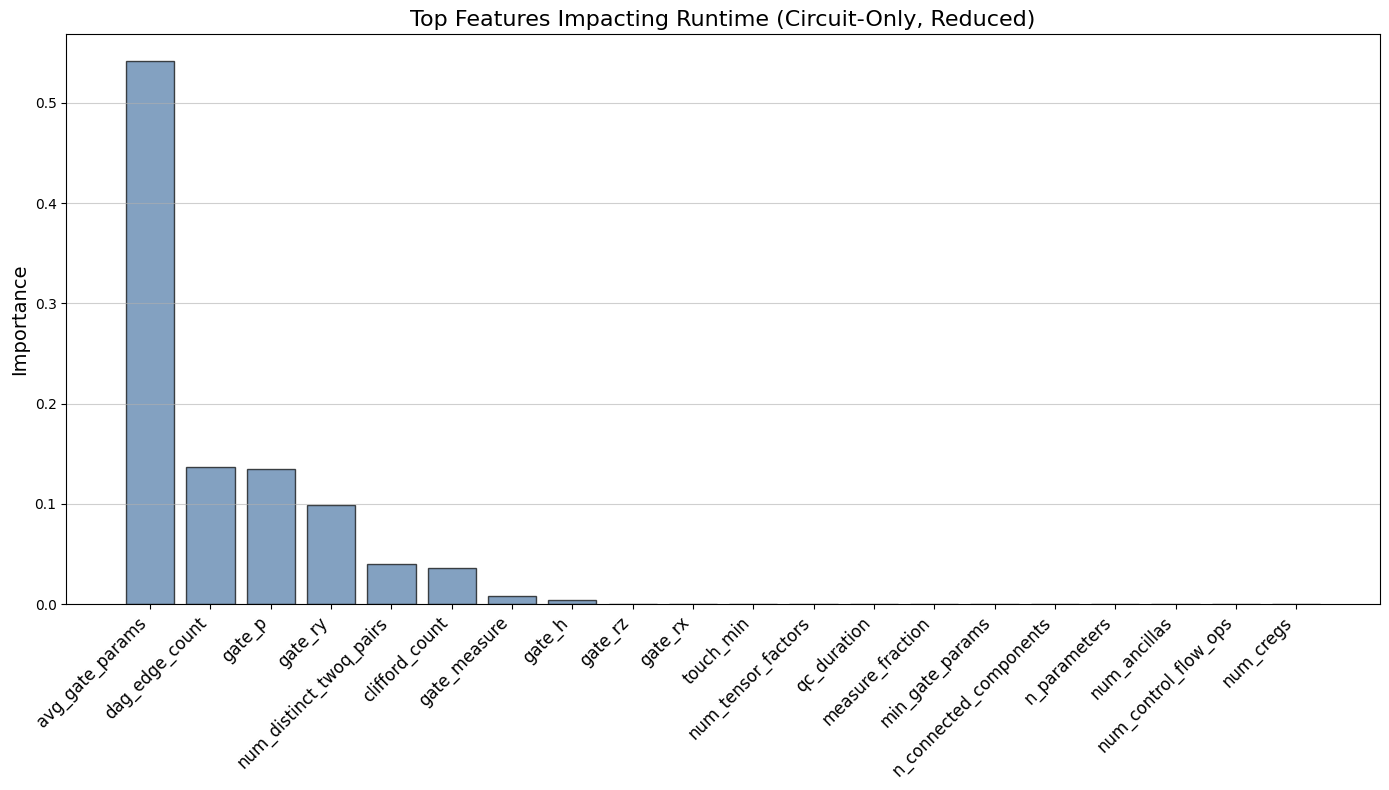

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import numpy as np

# Target = mean_ms from original (unprocessed) DF for readability
y = estimate_runtime_df["mean_ms"].values
X = estimate_runtime_df_processed[reduced_features].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

top_k = min(20, len(reduced_features))

plt.figure(figsize=(14, 8))
plt.bar(range(top_k), importances[indices[:top_k]], edgecolor="black", alpha=0.7, color=colors[0])
plt.xticks(range(top_k), [reduced_features[i] for i in indices[:top_k]], rotation=45, ha="right", fontsize=TICK_FONTSIZE)
plt.ylabel("Importance", fontsize=LABEL_FONTSIZE)
plt.title("Top Features Impacting Runtime (Circuit-Only, Reduced)", fontsize=TITLE_FONTSIZE)
plt.grid(True, axis="y", alpha=GRID_ALPHA)
plt.tight_layout()
plt.show()

## 7. Problem 1 — Estimate Runtime (Regression)

Predict `mean_ms` using **circuit metadata + backend / device / run_mode + n_nodes + n_processes**.
We exclude runtime statistics (`mean_ms`, `std_ms`) from features and use a one-hot pipeline.

MAE : 22086.180 ms
RMSE: 76314.400 ms
R^2 : 0.529


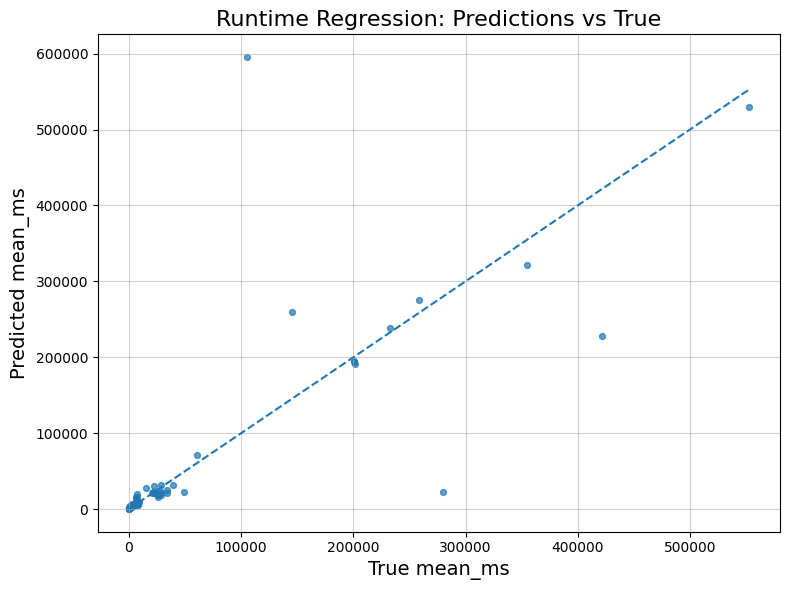

In [9]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features (raw, to allow encoding inside pipeline)
drop_cols = ["mean_ms", "std_ms"]
X_full = estimate_runtime_df.drop(columns=[c for c in drop_cols if c in estimate_runtime_df.columns])
y_full = estimate_runtime_df["mean_ms"].values

# Split categorical vs numeric
categorical_cols = X_full.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_full.select_dtypes(exclude=["object"]).columns.tolist()

# Version-safe encoder
try:
	ohe_full = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
	ohe_full = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
	[("categorical", ohe_full, categorical_cols),
	 ("numeric", "passthrough", numeric_cols)]
)

reg_model = Pipeline(steps=[
	("preprocessor", preprocessor),
	("regressor", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1))
])

from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

reg_model.fit(X_tr, y_tr)
y_hat = reg_model.predict(X_te)

mae = mean_absolute_error(y_te, y_hat)
rmse = np.sqrt(((y_te - y_hat)**2).mean())
from sklearn.metrics import r2_score
r2 = r2_score(y_te, y_hat)

print(f"MAE : {mae:.3f} ms")
print(f"RMSE: {rmse:.3f} ms")
print(f"R^2 : {r2:.3f}")

# Residual plot
plt.figure(figsize=(8,6))
plt.scatter(y_te, y_hat, s=18, alpha=0.7)
plt.plot([min(y_te), max(y_te)], [min(y_te), max(y_te)], linestyle='--')
plt.xlabel("True mean_ms", fontsize=LABEL_FONTSIZE)
plt.ylabel("Predicted mean_ms", fontsize=LABEL_FONTSIZE)
plt.title("Runtime Regression: Predictions vs True", fontsize=TITLE_FONTSIZE)
plt.grid(True, alpha=GRID_ALPHA)
plt.tight_layout()
plt.show()

## 8. Problem 2 — Best Backend (Classification)

Predict `best_backend` from **circuit metadata + execution parameters** in `best_backend_df`.
We exclude `best_runtime` from features.

Accuracy: 0.875
              precision    recall  f1-score   support

        ionq       0.00      0.00      0.00         1
      nwqsim       0.86      1.00      0.92        12
   qiskitaer       1.00      0.67      0.80         3

    accuracy                           0.88        16
   macro avg       0.62      0.56      0.57        16
weighted avg       0.83      0.88      0.84        16



/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/results_analysis/jupyter_notebooks/.venv/lib64/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/results_analysis/jupyter_notebooks/.venv/lib64/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/results_analysis/jupyter_notebooks/.venv/lib64/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedM

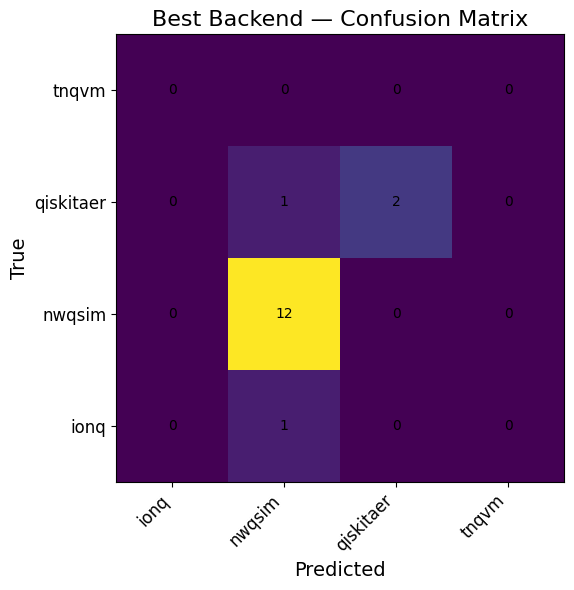

In [10]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

# Prepare features/target
X_cls = best_backend_df.drop(columns=[c for c in ["best_backend","best_runtime"] if c in best_backend_df.columns])
y_cls = best_backend_df["best_backend"]

# Split categorical vs numeric
categorical_cols_cls = X_cls.select_dtypes(include=["object"]).columns.tolist()
numeric_cols_cls = X_cls.select_dtypes(exclude=["object"]).columns.tolist()

# Version-safe encoder
try:
	ohe_cls = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
	ohe_cls = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor_cls = ColumnTransformer(
	[("categorical", ohe_cls, categorical_cols_cls),
	 ("numeric", "passthrough", numeric_cols_cls)]
)

clf = Pipeline(steps=[
	("preprocessor", preprocessor_cls),
	("model", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

from sklearn.model_selection import train_test_split
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

clf.fit(Xc_tr, yc_tr)
yc_hat = clf.predict(Xc_te)

acc = accuracy_score(yc_te, yc_hat)
print(f"Accuracy: {acc:.3f}")
print(classification_report(yc_te, yc_hat))

# Confusion matrix (matplotlib only)
import numpy as np
from sklearn.metrics import confusion_matrix
labels = sorted(y_cls.unique().tolist())
cm = confusion_matrix(yc_te, yc_hat, labels=labels)

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm, origin='lower', cmap=None)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=TICK_FONTSIZE)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=TICK_FONTSIZE)
for i in range(cm.shape[0]):
	for j in range(cm.shape[1]):
		ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=10)
ax.set_xlabel("Predicted", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("True", fontsize=LABEL_FONTSIZE)
ax.set_title("Best Backend — Confusion Matrix", fontsize=TITLE_FONTSIZE)
plt.tight_layout()
plt.show()

## 9. Additional Visualizations

- PCA on the **reduced circuit feature set** to inspect variance structure.
- Correlation matrix of the **reduced set** (matplotlib-only heatmap).

In [ ]:
# from sklearn.decomposition import PCA
# import numpy as np

# X_red = estimate_runtime_df_processed[reduced_features].values

# # PCA fit
# pca = PCA(n_components=min(10, X_red.shape[1]))
# X_pca = pca.fit_transform(X_red)

# # Explained variance plot
# plt.figure(figsize=(10,6))
# plt.plot(range(1, pca.n_components_+1), np.cumsum(pca.explained_variance_ratio_), marker='o')
# plt.xlabel("Number of Components", fontsize=LABEL_FONTSIZE)
# plt.ylabel("Cumulative Explained Variance", fontsize=LABEL_FONTSIZE)
# plt.title("PCA — Cumulative Explained Variance (Reduced Circuit Features)", fontsize=TITLE_FONTSIZE)
# plt.grid(True, alpha=GRID_ALPHA)
# plt.tight_layout()
# plt.show()

# # Scatter of first two PCs
# if pca.n_components_ >= 2:
# 	plt.figure(figsize=(8,6))
# 	plt.scatter(X_pca[:,0], X_pca[:,1], s=12, alpha=0.7)
# 	plt.xlabel("PC1", fontsize=LABEL_FONTSIZE)
# 	plt.ylabel("PC2", fontsize=LABEL_FONTSIZE)
# 	plt.title("PCA Scatter (First Two Components)", fontsize=TITLE_FONTSIZE)
# 	plt.grid(True, alpha=GRID_ALPHA)
# 	plt.tight_layout()
# 	plt.show()

# # Correlation matrix on reduced set
# corr_red = np.corrcoef(X_red, rowvar=False)
# plt.figure(figsize=(12,10))
# im = plt.imshow(np.abs(corr_red), vmin=0, vmax=1, origin='lower', aspect='auto')
# plt.colorbar(im, fraction=0.046, pad=0.04)
# plt.xticks(range(len(reduced_features)), reduced_features, rotation=90, fontsize=TICK_FONTSIZE)
# plt.yticks(range(len(reduced_features)), reduced_features, fontsize=TICK_FONTSIZE)
# plt.title("Correlation Matrix (Reduced Circuit Features)", fontsize=TITLE_FONTSIZE)
# plt.tight_layout()
# plt.show()